# 📊 Exploratory Data Analysis (EDA)

This notebook performs **Exploratory Data Analysis** on the given dataset (`symtoms_df.csv`).  
It covers:

- Dataset overview  
- Missing values & duplicates  
- Descriptive statistics  
- Univariate & Bivariate analysis  
- Visualizations  
- Outlier detection  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('..//backend/Training/MasterData/symtoms_df.csv')
print("Dataset Uploaded Sucessfully!")

Dataset Uploaded Sucessfully!


# Dataset Overview

In [ ]:
print("🔹 Dataset Shape:", df.shape)
df.head()

🔹 Dataset Shape: (4920, 6)


,,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4
0,0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches
1,1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN
2,2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN
3,3,Fungal infection,itching,skin_rash,dischromic _patches,NaN
4,4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN


In [4]:
# Dataset Info & Quality Check
print("\n🔹 Data Info:")
df.info()



🔹 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0                                             4920 non-null   int64 
 1   Disease                                   4920 non-null   object
 2   Symptom_1                                 4920 non-null   object
 3   Symptom_2                                 4920 non-null   object
 4   Symptom_3                                 4920 non-null   object
 5   Symptom_4                                 4572 non-null   object
dtypes: int64(1), object(5)
memory usage: 230.8+ KB


In [5]:
print("\n🔹 Column Names:", df.columns.tolist())
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Column Names: ['     ', 'Disease                                 ', 'Symptom_1                   ', 'Symptom_2                   ', 'Symptom_3                    ', 'Symptom_4']

🔹 Data Types:
                                              int64
Disease                                     object
Symptom_1                                   object
Symptom_2                                   object
Symptom_3                                   object
Symptom_4                                   object
dtype: object

🔹 Missing Values:
                                               0
Disease                                       0
Symptom_1                                     0
Symptom_2                                     0
Symptom_3                                     0
Symptom_4                                   348
dtype: int64

🔹 Duplicate Rows: 0


In [6]:
# Descriptive Statistics
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
,4920.0,NaN,NaN,NaN,2459.5,1420.425992,0.0,1229.75,2459.5,3689.25,4919.0
Disease,4920,41,Fungal infection,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_1,4920,34,vomiting,822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_2,4920,48,vomiting,870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_3,4920,54,fatigue,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Symptom_4,4572,50,high_fever,378,NaN,NaN,NaN,NaN,NaN,NaN,NaN


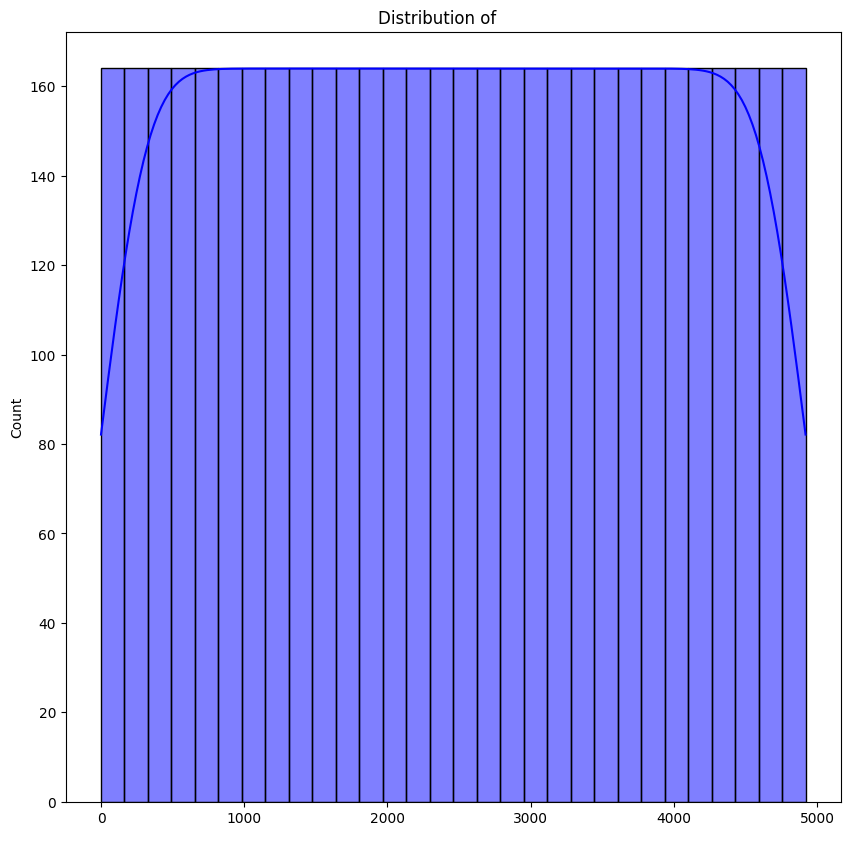

C:\Users\hp\AppData\Local\Temp\ipykernel_5908\124443483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")


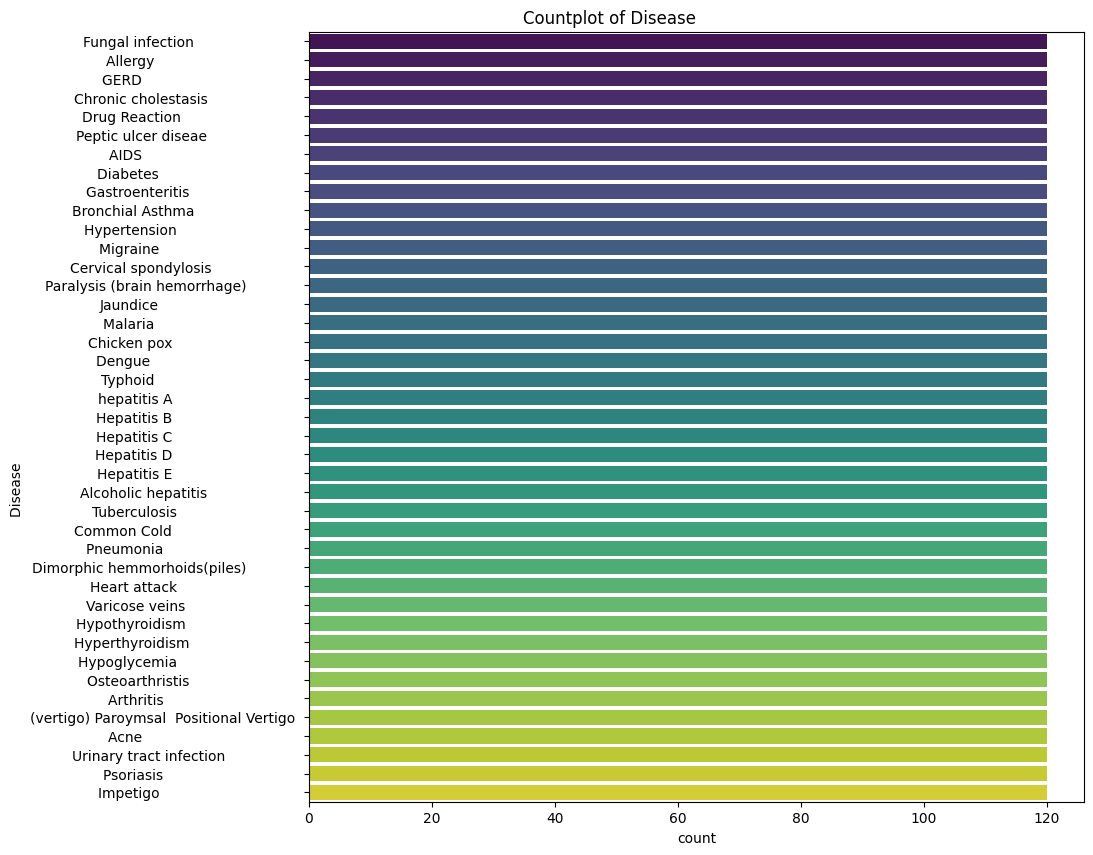

C:\Users\hp\AppData\Local\Temp\ipykernel_5908\124443483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")


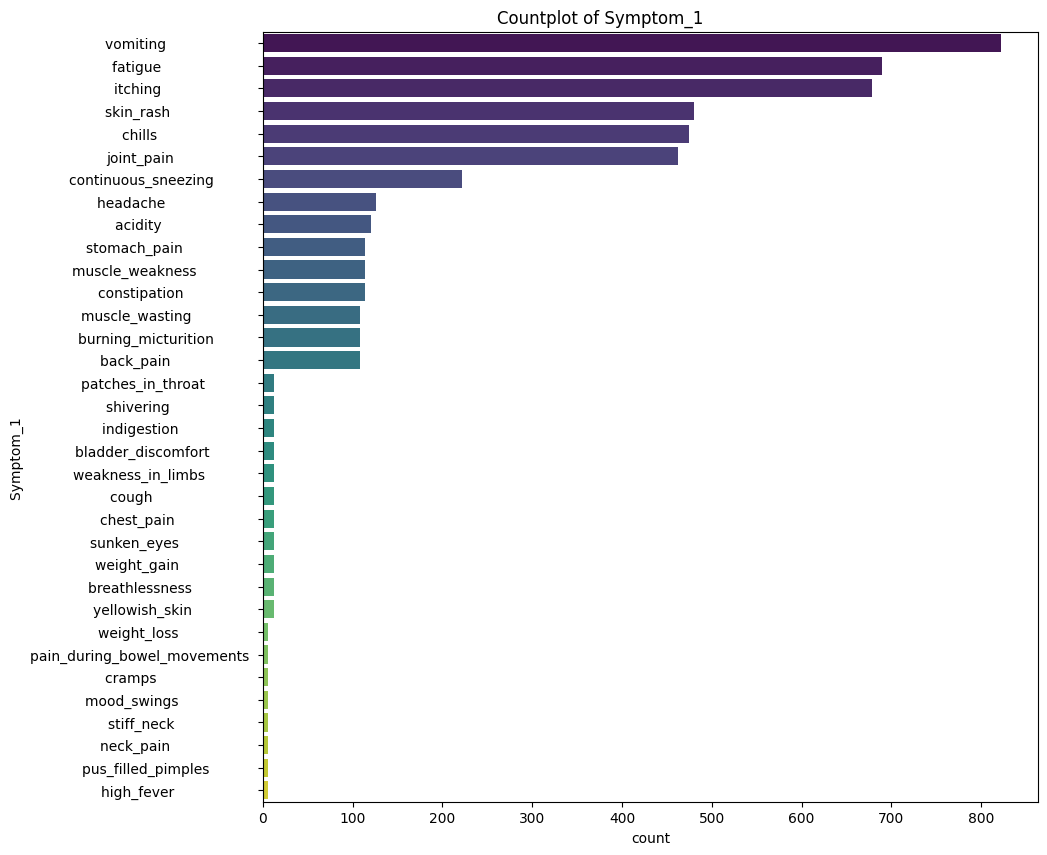

C:\Users\hp\AppData\Local\Temp\ipykernel_5908\124443483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")


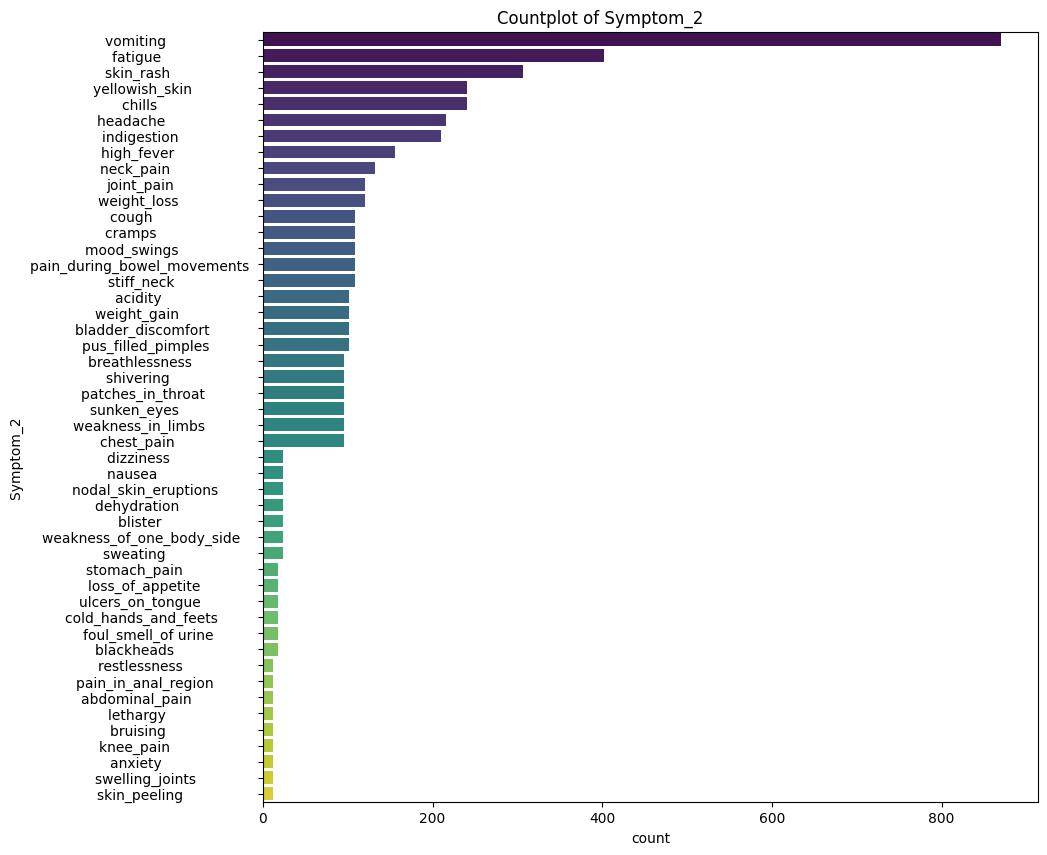

C:\Users\hp\AppData\Local\Temp\ipykernel_5908\124443483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")


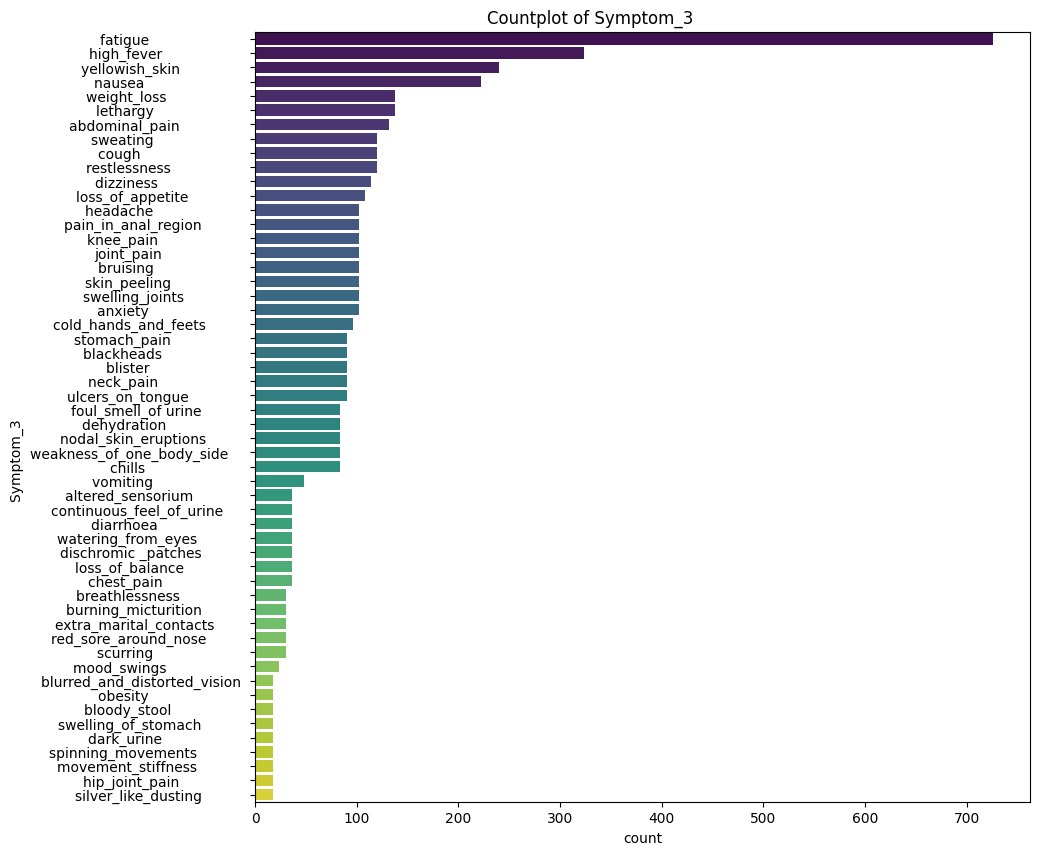

C:\Users\hp\AppData\Local\Temp\ipykernel_5908\124443483.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")


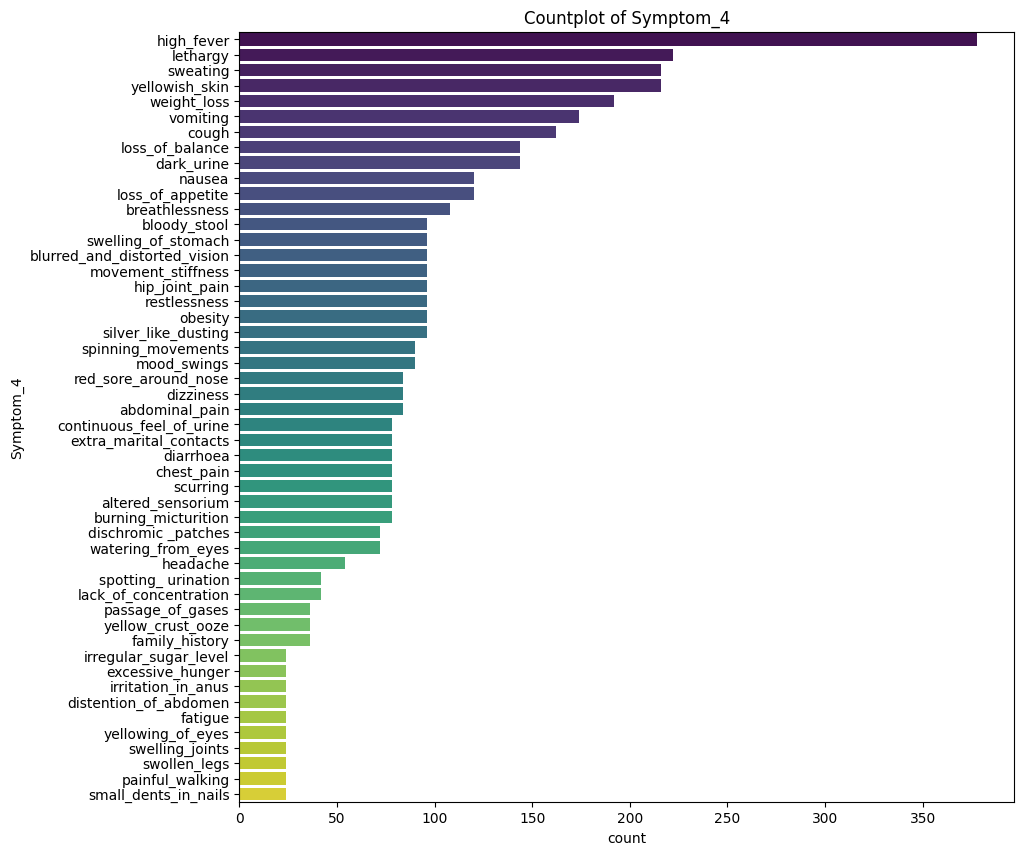

In [7]:
# Univariate Analysis
for col in df.columns:
    plt.figure(figsize=(10,10))
    if df[col].dtype == 'object':
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette="viridis")
        plt.title(f"Countplot of {col}")
        plt.show()
    else:
        sns.histplot(df[col], kde=True, bins=30, color="blue")
        plt.title(f"Distribution of {col}")
        plt.show()

In [8]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

In [9]:
# Pairplot (if dataset is small)
if df.shape[1] <= 8 and df.shape[0] <= 1000:
    sns.pairplot(df[numeric_cols])
    plt.show()

In [10]:
# Crosstab for Categorical Features
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) >= 2:
    for i in range(len(cat_cols)-1):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[i+1]])
        print(f"\n🔹 Crosstab between {cat_cols[i]} and {cat_cols[i+1]}:\n", ct)


🔹 Crosstab between Disease                                  and Symptom_1                   :
 Symptom_1                                 acidity                       \
Disease                                                                  
(vertigo) Paroymsal  Positional Vertigo                              0   
AIDS                                                                 0   
Acne                                                                 0   
Alcoholic hepatitis                                                  0   
Allergy                                                              0   
Arthritis                                                            0   
Bronchial Asthma                                                     0   
Cervical spondylosis                                                 0   
Chicken pox                                                          0   
Chronic cholestasis                                                  0   
Common Cold     

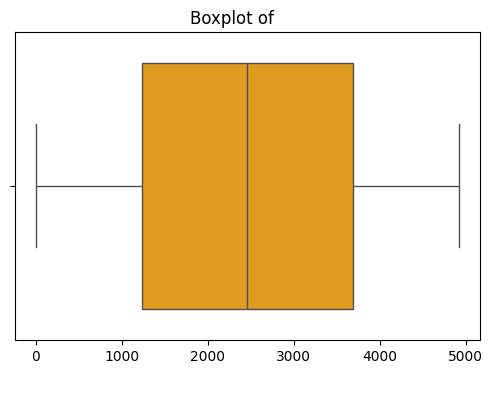

In [11]:
# Outlier Detection (Boxplots)
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="orange")
    plt.title(f"Boxplot of {col}")
    plt.show()

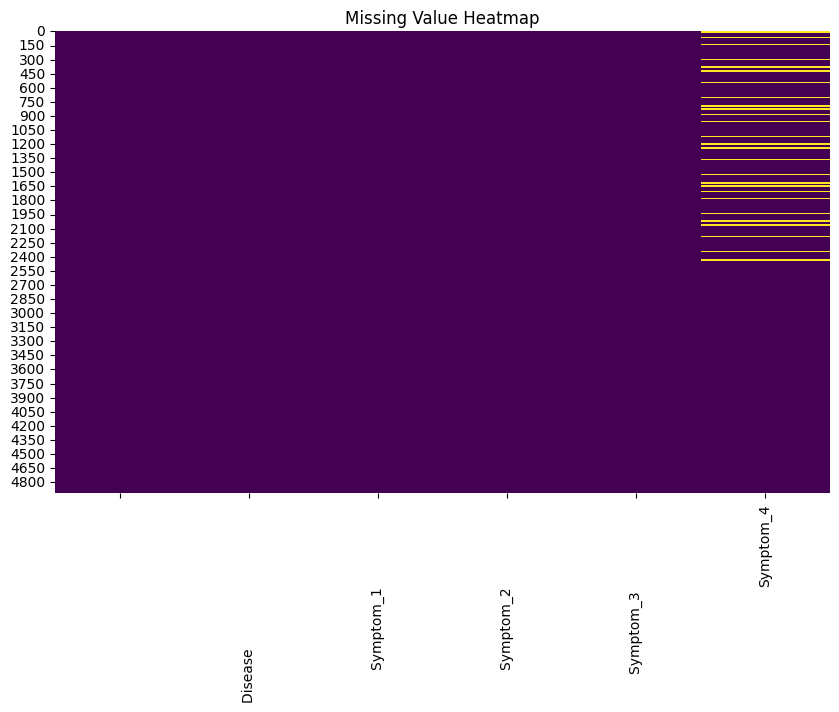

In [12]:
# Missing Value Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()

###  EDA Completed Successfully!